In [0]:
# Electricity Price Prediction using Machine Learning

## Sedat Aydin  
## Big Data Analytics  
##Project: Technical Project  
##Models Used: Linear Regression and Random Forest  
##Platform: Apache Spark (PySpark) – Databricks

## Project Overview
###This project aims to predict electricity prices using historical electricity generation and consumption data. Machine learning models including Linear Regression and Random Forest were implemented using PySpark.The models were trained and evaluated using RMSE and R² metrics, and their performance was compared. The analysis also investigates the importance of different energy sources in predicting electricity prices.

df = spark.table("workspace.default.full_data")

display(df.limit(5))

time,consumption_MWh,total_generation_MWh,natural_gas,hydro_dam,lignite,hydro_river,coal_imported,wind,solar,fuel_oil,geothermal,asphaltite_coal,hard_coal,biomass,naphtha,LNG,international,waste_heat,TRY/MWh,USD/MWh,EUR/MWh
01:01:2018:00:00,27412.81,27412.81,6926.78,4820.4,5226.32,1900.32,5314.05,1179.51,0.0,176.6,801.09,278.2,189.5,210.96,0.0,0.0,297.0,92.08,207.6,55.04,45.97
01:01:2018:01:00,26324.39,26324.39,6603.44,3644.32,5277.19,1877.83,5715.61,1148.46,0.0,174.2,803.21,284.82,205.5,211.67,0.0,0.0,287.0,91.14,205.34,54.44,45.47
01:01:2018:02:00,24635.32,24635.32,6040.77,2711.0,5325.47,1708.49,5701.37,1216.38,0.0,177.91,804.28,278.2,201.5,209.89,0.0,0.0,169.0,91.06,164.94,43.73,36.53
01:01:2018:03:00,23872.12,23872.12,5938.46,2524.37,5265.91,1662.59,5205.43,1298.11,0.0,171.5,805.61,271.57,211.5,211.24,0.0,0.0,214.0,91.83,154.52,40.97,34.22
01:01:2018:04:00,23194.89,23194.89,5665.41,2462.71,5282.88,1697.96,4804.19,1220.91,0.0,165.0,806.01,273.78,307.5,214.31,0.0,0.0,203.0,91.23,112.64,29.86,24.95


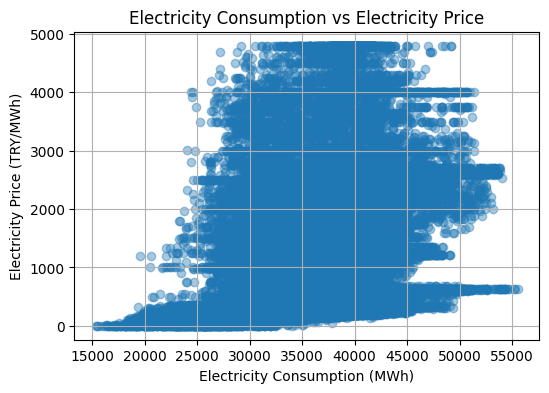

In [0]:
# Scatter Plot: Electricity Consumption vs Electricity Price

import matplotlib.pyplot as plt

# Spark dataframe -> pandas dataframe
df_pd = df.select("consumption_MWh","TRY/MWh").toPandas()

plt.figure(figsize=(6,4))

plt.scatter(df_pd["consumption_MWh"], df_pd["TRY/MWh"], alpha=0.4)

plt.xlabel("Electricity Consumption (MWh)")
plt.ylabel("Electricity Price (TRY/MWh)")
plt.title("Electricity Consumption vs Electricity Price")

plt.grid(True)
plt.show()


In [0]:
# Basic dataset information summary

row_count = df.count()
column_count = len(df.columns)

print("DATASET SUMMARY")
print("---------------------------")
print(f"Number of rows: {row_count}")
print(f"Number of columns: {column_count}")

print("\nCOLUMN NAMES")
print("---------------------------")
print(df.columns)

print("\nSCHEMA (DATA TYPES)")
print("---------------------------")
df.printSchema()

DATASET SUMMARY
---------------------------
Number of rows: 52584
Number of columns: 22

COLUMN NAMES
---------------------------
['time', 'consumption_MWh', 'total_generation_MWh', 'natural_gas', 'hydro_dam', 'lignite', 'hydro_river', 'coal_imported', 'wind', 'solar', 'fuel_oil', 'geothermal', 'asphaltite_coal', 'hard_coal', 'biomass', 'naphtha', 'LNG', 'international', 'waste_heat', 'TRY/MWh', 'USD/MWh', 'EUR/MWh']

SCHEMA (DATA TYPES)
---------------------------
root
 |-- time: string (nullable = true)
 |-- consumption_MWh: double (nullable = true)
 |-- total_generation_MWh: double (nullable = true)
 |-- natural_gas: double (nullable = true)
 |-- hydro_dam: double (nullable = true)
 |-- lignite: double (nullable = true)
 |-- hydro_river: double (nullable = true)
 |-- coal_imported: double (nullable = true)
 |-- wind: double (nullable = true)
 |-- solar: double (nullable = true)
 |-- fuel_oil: double (nullable = true)
 |-- geothermal: double (nullable = true)
 |-- asphaltite_coal: do

In [0]:
# Generate basic descriptive statistics for key numerical variables (consumption, generation and electricity prices)
display(df.select("consumption_MWh", "total_generation_MWh", "TRY/MWh", "USD/MWh", "EUR/MWh").describe())

summary,consumption_MWh,total_generation_MWh,TRY/MWh,USD/MWh,EUR/MWh
count,52584,52584,52584,52584,52584
mean,35166.891648600424,34399.243138217025,996.1390208048034,72.19021090065401,65.79322360413842
stddev,5743.832244340094,5272.179656206012,1126.2334155943583,49.81515634163871,49.43167448288784
min,15333.3,15333.3,0.0,0.0,0.0
max,55575.02,51285.69,4800.0,264.17,271.63


In [0]:
from pyspark.sql.functions import col, sum

missing = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
display(missing)

# check if there are any missing values
total_missing = missing.toPandas().sum(axis=1)[0]

if total_missing == 0:
    print("No missing values were detected in the dataset.")
else:
    print(f"The dataset contains {total_missing} missing values.")

time,consumption_MWh,total_generation_MWh,natural_gas,hydro_dam,lignite,hydro_river,coal_imported,wind,solar,fuel_oil,geothermal,asphaltite_coal,hard_coal,biomass,naphtha,LNG,international,waste_heat,TRY/MWh,USD/MWh,EUR/MWh
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


No missing values were detected in the dataset.


In [0]:
# Check for duplicate rows in the dataset

total_rows = df.count()                # counts total number of rows in the dataset
distinct_rows = df.dropDuplicates().count()   # counts rows after removing duplicates

duplicate_rows = total_rows - distinct_rows   # calculates how many duplicate rows exist

print("Total rows:", total_rows)
print("Distinct rows:", distinct_rows)
print("Duplicate rows:", duplicate_rows)

# interpret the result
if duplicate_rows == 0:
    print("No duplicate rows were detected in the dataset.")
else:
    print(f"The dataset contains {duplicate_rows} duplicate rows.")

Total rows: 52584
Distinct rows: 52584
Duplicate rows: 0
No duplicate rows were detected in the dataset.


In [0]:
# Check for invalid negative values in key variables

negative_consumption = df.filter(df["consumption_MWh"] < 0).count()   # counts rows with negative consumption
negative_generation = df.filter(df["total_generation_MWh"] < 0).count()   # counts rows with negative total generation
negative_try_price = df.filter(df["TRY/MWh"] < 0).count()   # counts rows with negative TRY price
negative_usd_price = df.filter(df["USD/MWh"] < 0).count()   # counts rows with negative USD price
negative_eur_price = df.filter(df["EUR/MWh"] < 0).count()   # counts rows with negative EUR price

print("Negative consumption rows:", negative_consumption)
print("Negative total generation rows:", negative_generation)
print("Negative TRY/MWh rows:", negative_try_price)
print("Negative USD/MWh rows:", negative_usd_price)
print("Negative EUR/MWh rows:", negative_eur_price)

if (negative_consumption == 0 and negative_generation == 0 and 
    negative_try_price == 0 and negative_usd_price == 0 and negative_eur_price == 0):
    print("No invalid negative values were detected in the main analytical variables.")
else:
    print("Some negative values were detected and should be examined further.")

Negative consumption rows: 0
Negative total generation rows: 0
Negative TRY/MWh rows: 0
Negative USD/MWh rows: 0
Negative EUR/MWh rows: 0
No invalid negative values were detected in the main analytical variables.


In [0]:
# Check the time coverage of the dataset

from pyspark.sql.functions import min, max

time_range = df.select(min("time").alias("start_time"), max("time").alias("end_time"))

result = time_range.collect()[0]

start_year = result["start_time"][-10:-6]
end_year = result["end_time"][-10:-6]

display(time_range)

print(f"The dataset contains hourly electricity data covering the period {start_year}–{end_year}.")

start_time,end_time
01:01:2018:00:00,31:12:2023:23:00


The dataset contains hourly electricity data covering the period 2018–2023.


In [0]:
# Convert the time column from string format to timestamp format

from pyspark.sql.functions import to_timestamp

df = df.withColumn("timestamp", to_timestamp("time", "dd:MM:yyyy:HH:mm"))

display(df.select("time", "timestamp").limit(5))

time,timestamp
01:01:2018:00:00,2018-01-01T00:00:00.000Z
01:01:2018:01:00,2018-01-01T01:00:00.000Z
01:01:2018:02:00,2018-01-01T02:00:00.000Z
01:01:2018:03:00,2018-01-01T03:00:00.000Z
01:01:2018:04:00,2018-01-01T04:00:00.000Z


In [0]:
# Create time-based features from the timestamp column

from pyspark.sql.functions import hour, month, year, dayofweek

df = df.withColumn("hour", hour("timestamp")) \
 .withColumn("month", month("timestamp")) \
 .withColumn("year", year("timestamp")) \
 .withColumn("day_of_week", dayofweek("timestamp"))

display(df.select("timestamp", "hour", "day_of_week", "month", "year").limit(5))

timestamp,hour,day_of_week,month,year
2018-01-01T00:00:00.000Z,0,2,1,2018
2018-01-01T01:00:00.000Z,1,2,1,2018
2018-01-01T02:00:00.000Z,2,2,1,2018
2018-01-01T03:00:00.000Z,3,2,1,2018
2018-01-01T04:00:00.000Z,4,2,1,2018


In [0]:
# Create weekend indicator (weekend vs weekday)

from pyspark.sql.functions import when, col

df = df.withColumn(
    "is_weekend",
    when(col("day_of_week").isin([1,7]), 1).otherwise(0)
)

display(df.select("timestamp","day_of_week","is_weekend").limit(10))

timestamp,day_of_week,is_weekend
2018-01-01T00:00:00.000Z,2,0
2018-01-01T01:00:00.000Z,2,0
2018-01-01T02:00:00.000Z,2,0
2018-01-01T03:00:00.000Z,2,0
2018-01-01T04:00:00.000Z,2,0
2018-01-01T05:00:00.000Z,2,0
2018-01-01T06:00:00.000Z,2,0
2018-01-01T07:00:00.000Z,2,0
2018-01-01T08:00:00.000Z,2,0
2018-01-01T09:00:00.000Z,2,0


In [0]:
# check if weekend values exist

display(df.groupBy("is_weekend").count())

is_weekend,count
0,37560
1,15024


In [0]:
# Verify that all newly created time features exist in the dataset

display(df.select(
    "timestamp",
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
).limit(5))

print("Time-based feature engineering completed successfully.")

timestamp,hour,day_of_week,month,year,is_weekend
2018-01-01T00:00:00.000Z,0,2,1,2018,0
2018-01-01T01:00:00.000Z,1,2,1,2018,0
2018-01-01T02:00:00.000Z,2,2,1,2018,0
2018-01-01T03:00:00.000Z,3,2,1,2018,0
2018-01-01T04:00:00.000Z,4,2,1,2018,0


Time-based feature engineering completed successfully.


In [0]:
# Descriptive statistics for electricity consumption

display(df.select("consumption_MWh").describe())

print("The average hourly electricity consumption is approximately 35,166 MWh, with values ranging from about 15,333 MWh to 55,575 MWh.")

summary,consumption_MWh
count,52584
mean,35166.891648600424
stddev,5743.832244340094
min,15333.3
max,55575.02


The average hourly electricity consumption is approximately 35,166 MWh, with values ranging from about 15,333 MWh to 55,575 MWh.


In [0]:
# Analyse hourly electricity demand pattern

hourly_demand = df.groupBy("hour").avg("consumption_MWh").orderBy("hour")
display(hourly_demand)

print("Electricity consumption tends to increase during daytime hours and decreases late at night.")

hour,avg(consumption_MWh)
0,33246.57005476951
1,31646.914746690978
2,30506.378758557712
3,29761.890625285327
4,29416.71946599723
5,29193.68994066635
6,29284.84112733907
7,30622.287480602463
8,34439.40860794152
9,36789.961775445074


Electricity consumption tends to increase during daytime hours and decreases late at night.


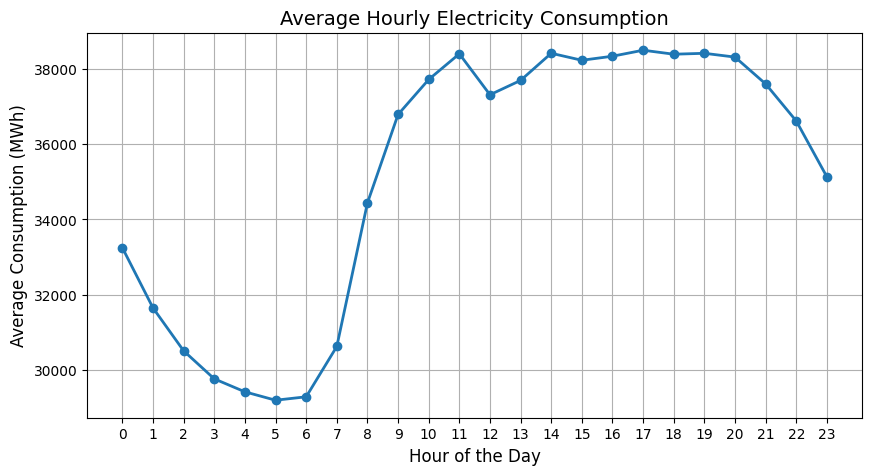

In [0]:
# Plot the average hourly electricity consumption pattern

# Convert the Spark DataFrame to Pandas for plotting
hourly_demand_pd = hourly_demand.toPandas()

import matplotlib.pyplot as plt

# Create the line chart
plt.figure(figsize=(10, 5))
plt.plot(
    hourly_demand_pd["hour"],
    hourly_demand_pd["avg(consumption_MWh)"],
    marker="o",
    linewidth=2,
    markersize=6
)

# Add chart title and axis labels
plt.title("Average Hourly Electricity Consumption", fontsize=14)
plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Average Consumption (MWh)", fontsize=12)

# Improve readability
plt.xticks(range(0, 24))
plt.grid(True)

# Display the chart
plt.show()

In [0]:
# Calculate the average electricity consumption for each month to examine seasonal patterns in electricity demand

monthly_demand = df.groupBy("month").avg("consumption_MWh").orderBy("month")

display(monthly_demand)

print("The table reports the average hourly electricity consumption for each month.")

month,avg(consumption_MWh)
1,35843.96799059142
2,35383.75929487182
3,34438.53545698929
4,32319.647442129743
5,31904.777298387166
6,34011.94693750001
7,38928.340524193605
8,39685.727668010724
9,36419.43324537031
10,32831.25276657711


The table reports the average hourly electricity consumption for each month.


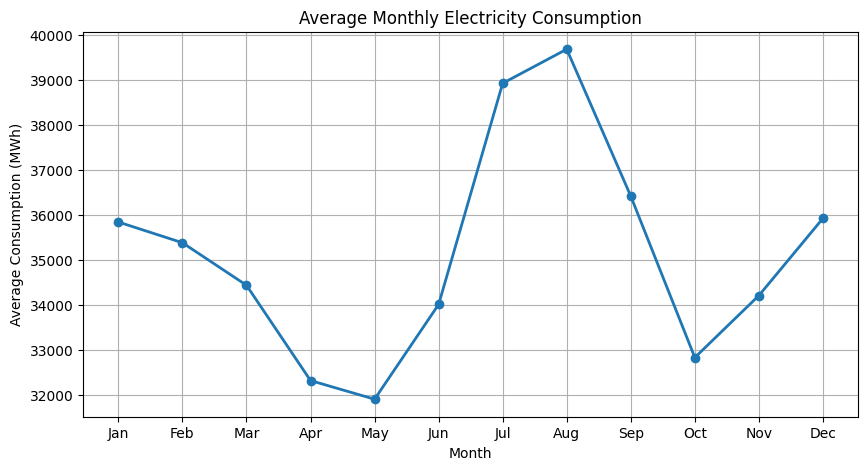

In [0]:
# Convert the Spark DataFrame to Pandas in order to plot the monthly electricity demand pattern

monthly_demand_pd = monthly_demand.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_demand_pd["month"],
    monthly_demand_pd["avg(consumption_MWh)"],
    marker="o",
    linewidth=2,
    markersize=6
)

plt.title("Average Monthly Electricity Consumption")
plt.xlabel("Month")
plt.ylabel("Average Consumption (MWh)")

plt.xticks(
    range(1,13),
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.grid(True)
plt.show()


In [0]:
# Calculate descriptive statistics for electricity price

display(df.select("TRY/MWh").describe())

print("The table reports summary statistics for the electricity price measured in TRY per MWh.")

summary,TRY/MWh
count,52584
mean,996.1390208048034
stddev,1126.2334155943583
min,0.0
max,4800.0


The table reports summary statistics for the electricity price measured in TRY per MWh.


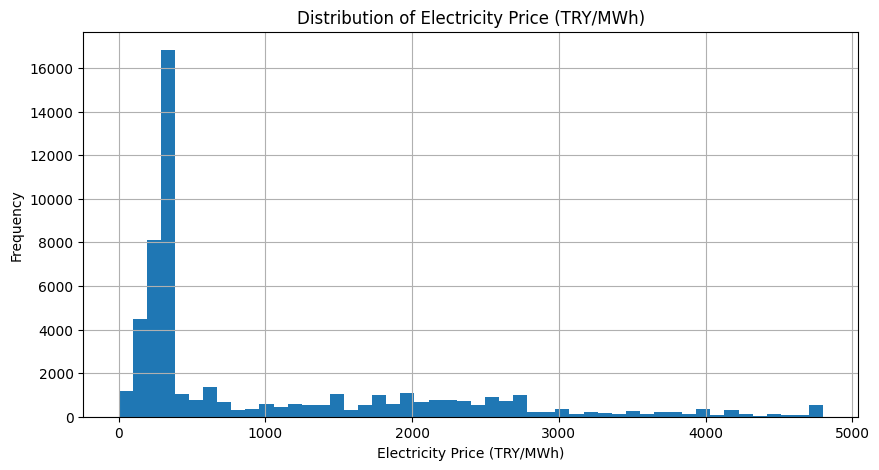

In [0]:
# Convert Spark DataFrame to Pandas to visualize the electricity price distribution

price_pd = df.select("TRY/MWh").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(price_pd["TRY/MWh"], bins=50)

plt.title("Distribution of Electricity Price (TRY/MWh)")
plt.xlabel("Electricity Price (TRY/MWh)")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()


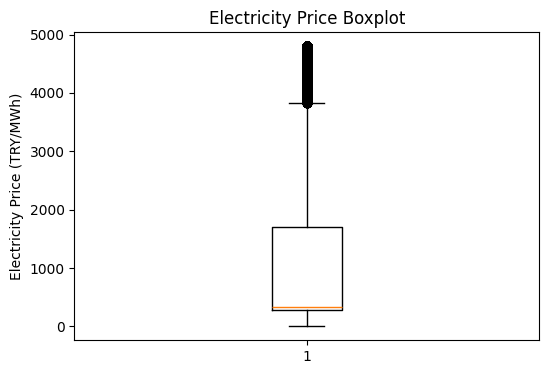

In [0]:
price_pd = df.select("TRY/MWh").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(price_pd["TRY/MWh"])

plt.ylabel("Electricity Price (TRY/MWh)")
plt.title("Electricity Price Boxplot")

plt.show()

In [0]:
# Examine the relationship between electricity demand and price

display(df.select("consumption_MWh","TRY/MWh").describe())

print("The table provides summary statistics for electricity demand and electricity price to support the analysis of their potential relationship.")

summary,consumption_MWh,TRY/MWh
count,52584,52584
mean,35166.891648600424,996.1390208048034
stddev,5743.832244340094,1126.2334155943583
min,15333.3,0.0
max,55575.02,4800.0


The table provides summary statistics for electricity demand and electricity price to support the analysis of their potential relationship.


/home/spark-7773cd5f-5e1e-4360-a1e3-bc/.ipykernel/1980/command-7604892928694976-1651740924:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = demand_price_pd.groupby("demand_bin")["TRY/MWh"].mean()


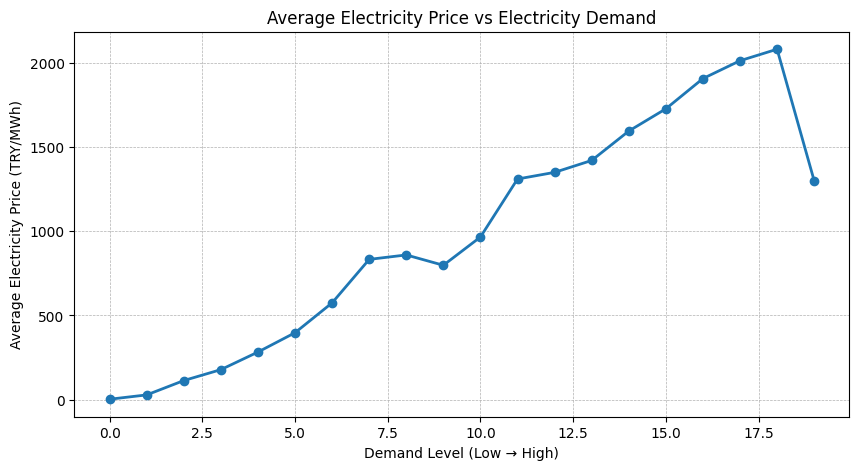

In [0]:
# Create demand bins to smooth the relationship between demand and price

import pandas as pd
import matplotlib.pyplot as plt

demand_price_pd = df.select("consumption_MWh","TRY/MWh").toPandas()

# create bins
demand_price_pd["demand_bin"] = pd.cut(demand_price_pd["consumption_MWh"], bins=20)

# calculate mean price for each bin
trend = demand_price_pd.groupby("demand_bin")["TRY/MWh"].mean()

plt.figure(figsize=(10,5))

plt.plot(trend.values, marker="o", linewidth=2)

plt.title("Average Electricity Price vs Electricity Demand")
plt.xlabel("Demand Level (Low → High)")
plt.ylabel("Average Electricity Price (TRY/MWh)")

plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

In [0]:
# Select numeric columns relevant for correlation analysis

corr_df = df.select(
    "consumption_MWh",
    "total_generation_MWh",
    "natural_gas",
    "coal_imported",
    "wind",
    "solar",
    "TRY/MWh"
).toPandas()

# Calculate correlation matrix
corr_matrix = corr_df.corr()

# Display correlation table
display(corr_matrix)

print("The table presents the correlation coefficients between key electricity market variables.")

consumption_MWh,total_generation_MWh,natural_gas,coal_imported,wind,solar,TRY/MWh
1.0,0.9598811706608997,0.6425242621718071,0.4026310258003353,0.2298626072198487,0.3836096048061517,0.3209644129966565
0.9598811706608997,1.0,0.6742790291268584,0.4442217270959308,0.22580596183071763,0.13824417120515586,0.26469277853701745
0.6425242621718071,0.6742790291268584,1.0,0.31392242761571426,-0.13011321277761653,0.035270329475195004,0.06760170680444101
0.4026310258003353,0.4442217270959308,0.31392242761571426,1.0,0.06145405607198011,0.044759232627145054,0.36273985015062127
0.2298626072198487,0.22580596183071763,-0.13011321277761653,0.06145405607198011,1.0,0.09134542946308603,0.19618752970132292
0.3836096048061517,0.13824417120515586,0.035270329475195004,0.044759232627145054,0.09134542946308603,1.0,0.35817204521883184
0.3209644129966565,0.26469277853701745,0.06760170680444101,0.36273985015062127,0.19618752970132292,0.35817204521883184,1.0


The table presents the correlation coefficients between key electricity market variables.


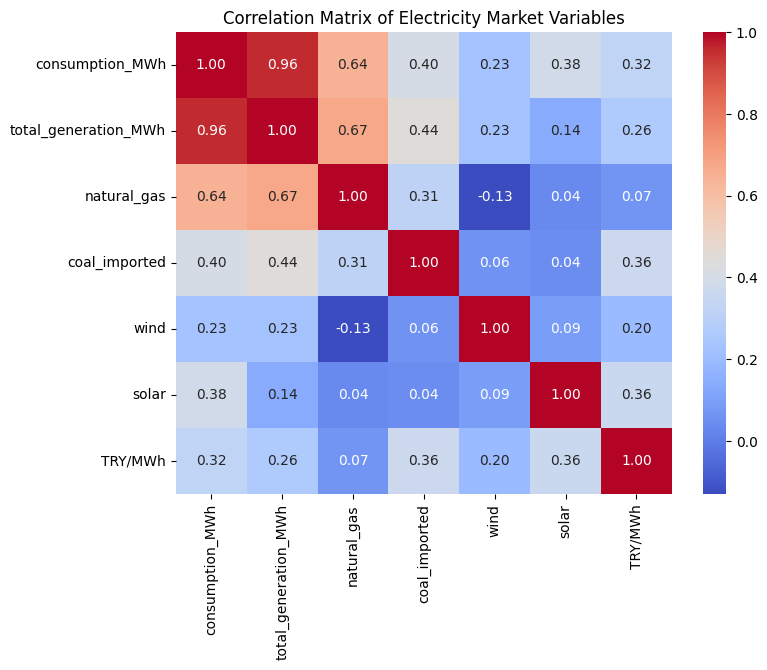

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Electricity Market Variables")

plt.show()


In [0]:
# Summary statistics for electricity price

display(df.select("TRY/MWh").describe())

print("The table summarizes the statistical distribution of electricity prices in the dataset.")

summary,TRY/MWh
count,52584
mean,996.1390208048034
stddev,1126.2334155943583
min,0.0
max,4800.0


The table summarizes the statistical distribution of electricity prices in the dataset.


In [0]:
# Define target variable (electricity price)

target = "TRY/MWh"

print("Target variable:", target)

Target variable: TRY/MWh


In [0]:
# Define feature variables for the model

features = [
    "consumption_MWh",
    "total_generation_MWh",
    "natural_gas",
    "coal_imported",
    "wind",
    "solar",
    "hour",
    "day_of_week",
    "month"
]

print("Selected feature variables:")
print(features)

Selected feature variables:
['consumption_MWh', 'total_generation_MWh', 'natural_gas', 'coal_imported', 'wind', 'solar', 'hour', 'day_of_week', 'month']


In [0]:
# Create modelling dataset

model_df = df.select(features + [target])

display(model_df.limit(10))

print("The modelling dataset contains selected feature variables and the target variable for electricity price prediction.")

consumption_MWh,total_generation_MWh,natural_gas,coal_imported,wind,solar,hour,day_of_week,month,TRY/MWh
27412.81,27412.81,6926.78,5314.05,1179.51,0.0,0,2,1,207.6
26324.39,26324.39,6603.44,5715.61,1148.46,0.0,1,2,1,205.34
24635.32,24635.32,6040.77,5701.37,1216.38,0.0,2,2,1,164.94
23872.12,23872.12,5938.46,5205.43,1298.11,0.0,3,2,1,154.52
23194.89,23194.89,5665.41,4804.19,1220.91,0.0,4,2,1,112.64
23071.96,23071.96,5738.26,4972.72,1138.81,0.0,5,2,1,105.02
23267.9,23267.9,5897.56,5066.64,1104.43,0.0,6,2,1,85.0
23875.44,23875.44,6544.48,5135.38,1109.53,0.0,7,2,1,119.89
24346.96,24346.96,7157.77,4767.37,1153.98,0.24,8,2,1,152.9
25804.69,25804.69,7589.14,5326.18,1180.34,1.46,9,2,1,193.27


The modelling dataset contains selected feature variables and the target variable for electricity price prediction.


In [0]:
# Split the modelling dataset into training and testing sets

train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())
print("The modelling dataset was split into 80% training data and 20% testing data.")

Training rows: 42005
Testing rows: 10579
The modelling dataset was split into 80% training data and 20% testing data.


In [0]:
# Preview the selected feature columns and target variable before vector assembly

display(train_df.select(features + [target]).limit(5))

print("The table shows the selected feature variables and the target variable before assembling them into a feature vector.")

consumption_MWh,total_generation_MWh,natural_gas,coal_imported,wind,solar,hour,day_of_week,month,TRY/MWh
15333.3,15333.3,895.31,1265.23,3319.72,56.02,7,2,5,2.0
15489.26,15489.26,1291.72,1085.12,3056.96,104.41,8,2,5,2.05
15595.52,15595.52,690.8,1305.58,3334.81,17.33,6,2,5,1.5
15814.02,15814.02,1263.76,1015.65,2777.65,140.94,9,2,5,0.1
16136.13,16136.13,763.67,1016.2,1676.01,63.01,7,3,5,3.02


The table shows the selected feature variables and the target variable before assembling them into a feature vector.


In [0]:
# Combine feature columns into a single feature vector required by Spark ML models

from pyspark.ml.feature import VectorAssembler

# Create a VectorAssembler to merge all feature columns into one "features" vector
assembler = VectorAssembler(inputCols=features, outputCol="features")

# Apply the transformation to the training and testing datasets
train_assembled = assembler.transform(train_df)
test_assembled = assembler.transform(test_df)

print("Feature columns were successfully assembled into a single vector for machine learning.")

Feature columns were successfully assembled into a single vector for machine learning.


In [0]:
# Display the assembled feature vector in a more readable array format

from pyspark.ml.functions import vector_to_array

display(
     train_assembled
    .select(vector_to_array("features").alias("feature_array"), target)
    .limit(5)
)

print("The selected feature variables were successfully combined into a single feature vector for Spark ML.")

feature_array,TRY/MWh
"List(15333.3, 15333.3, 895.31, 1265.23, 3319.72, 56.02, 7.0, 2.0, 5.0)",2.0
"List(15489.26, 15489.26, 1291.72, 1085.12, 3056.96, 104.41, 8.0, 2.0, 5.0)",2.05
"List(15595.52, 15595.52, 690.8, 1305.58, 3334.81, 17.33, 6.0, 2.0, 5.0)",1.5
"List(15814.02, 15814.02, 1263.76, 1015.65, 2777.65, 140.94, 9.0, 2.0, 5.0)",0.1
"List(16136.13, 16136.13, 763.67, 1016.2, 1676.01, 63.01, 7.0, 3.0, 5.0)",3.02


The selected feature variables were successfully combined into a single feature vector for Spark ML.


In [0]:
# Train a Linear Regression model to predict electricity price

from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol=target)

lr_model = lr.fit(train_assembled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [0]:
# Generate predictions on the test dataset

lr_predictions = lr_model.transform(test_assembled)

display(lr_predictions.select(target, "prediction").limit(10))

print("Predictions were generated for the test dataset.")

TRY/MWh,prediction
0.86,-479.97868306568944
0.0,-533.7280484016169
0.0,-478.86192653206626
0.0,-490.772874609293
8.0,-398.71458338929347
1.0,-445.81254919059893
0.0,-511.33363347347404
0.0,-414.8770337598007
0.85,-512.6802056916188
1.0,-437.1970610609774


Predictions were generated for the test dataset.


In [0]:
# Evaluate Linear Regression model performance

from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
r2_evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="r2")

lr_rmse = rmse_evaluator.evaluate(lr_predictions)
lr_r2 = r2_evaluator.evaluate(lr_predictions)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²:", lr_r2)

print("The Linear Regression model was evaluated using RMSE and R-squared.")

Linear Regression RMSE: 948.7316844862944
Linear Regression R²: 0.2892696909641239
The Linear Regression model was evaluated using RMSE and R-squared.


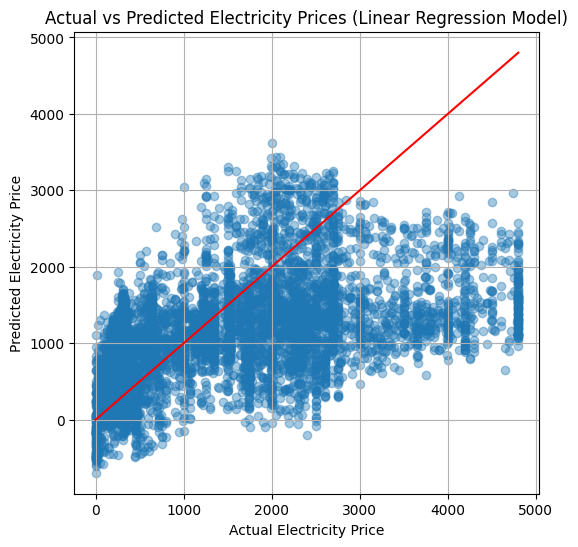

In [0]:
# Visualise Actual vs Predicted electricity prices for the Linear Regression model

lr_pd = lr_predictions.select(target, "prediction").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(lr_pd[target], lr_pd["prediction"], alpha=0.4)

plt.xlabel("Actual Electricity Price")
plt.ylabel("Predicted Electricity Price")

plt.title("Actual vs Predicted Electricity Prices (Linear Regression Model)")

plt.plot(
    [lr_pd[target].min(), lr_pd[target].max()],
    [lr_pd[target].min(), lr_pd[target].max()],
    color="red"
)

plt.grid(True)

plt.show()


In [0]:
# Train a Random Forest Regression model to predict electricity price

from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target,
    numTrees=100,
    maxDepth=8,
    seed=42
)

rf_model = rf.fit(train_assembled)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [0]:
# Generate predictions on the test dataset using the Random Forest model

rf_predictions = rf_model.transform(test_assembled)

display(rf_predictions.select(target, "prediction").limit(10))

print("Predictions were generated for the test dataset using the Random Forest model.")

TRY/MWh,prediction
0.86,128.88355338564884
0.0,173.2281245415969
0.0,127.90143009898391
0.0,127.90143009898391
8.0,159.29738937916298
1.0,128.88355338564884
0.0,160.93908058097836
0.0,216.85396796925153
0.85,239.940015991964
1.0,150.78365120095708


Predictions were generated for the test dataset using the Random Forest model.


In [0]:
# Evaluate Random Forest model performance

from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
r2_evaluator = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="r2")

rf_rmse = rmse_evaluator.evaluate(rf_predictions)
rf_r2 = r2_evaluator.evaluate(rf_predictions)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

print("The Random Forest model was evaluated using RMSE and R-squared.")

Random Forest RMSE: 651.3138103712954
Random Forest R²: 0.665035640142651
The Random Forest model was evaluated using RMSE and R-squared.


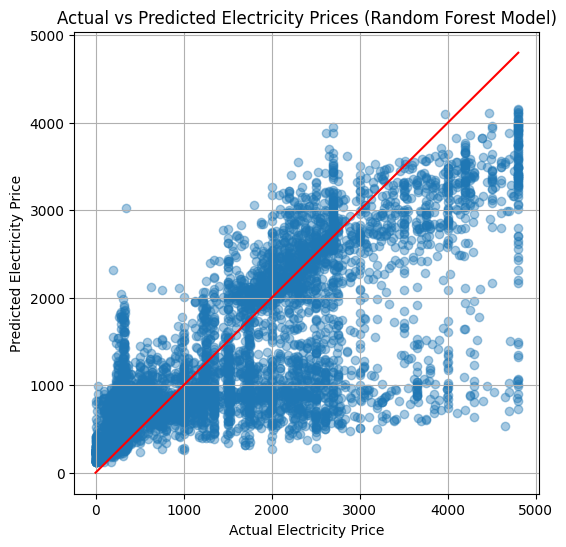

In [0]:
# Visualise Actual vs Predicted electricity prices for the Random Forest model

rf_pd = rf_predictions.select(target, "prediction").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(rf_pd[target], rf_pd["prediction"], alpha=0.4)

plt.xlabel("Actual Electricity Price")
plt.ylabel("Predicted Electricity Price")

plt.title("Actual vs Predicted Electricity Prices (Random Forest Model)")

plt.plot(
    [rf_pd[target].min(), rf_pd[target].max()],
    [rf_pd[target].min(), rf_pd[target].max()],
    color="red"
)

plt.grid(True)

plt.show()


Feature,Importance
coal_imported,0.5188914185629999
solar,0.1952427593017629
consumption_MWh,0.06346023025596499
natural_gas,0.04984149522384034
month,0.04570084390555673
wind,0.04189485523280982
total_generation_MWh,0.04103377706296957
hour,0.03924086241114491
day_of_week,0.0046937580429507455


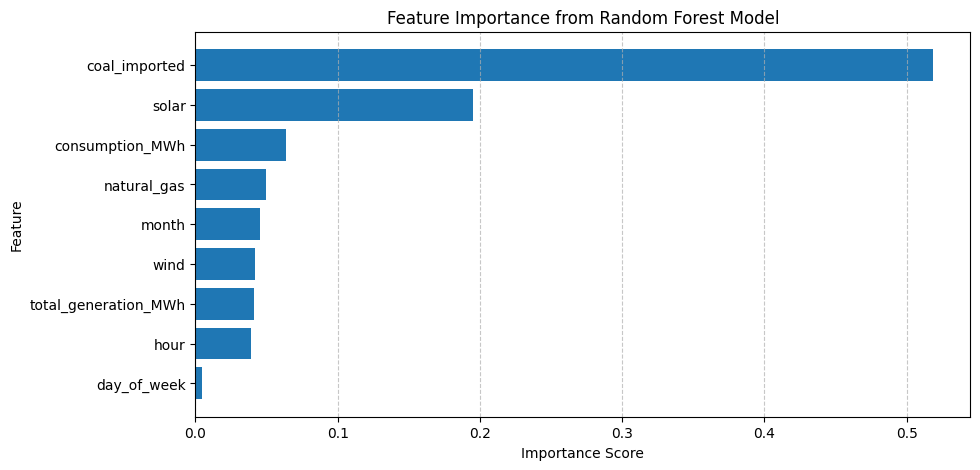

In [0]:
# Visualise feature importance from the Random Forest model

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.featureImportances.toArray()
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(10,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance from Random Forest Model")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()


In [0]:
# Compare the performance of the Linear Regression and Random Forest models

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

display(comparison)

print("The table compares the predictive performance of the Linear Regression and Random Forest models.")

Model,RMSE,R2
Linear Regression,948.7316844862944,0.2892696909641239
Random Forest,651.3138103712954,0.665035640142651


The table compares the predictive performance of the Linear Regression and Random Forest models.


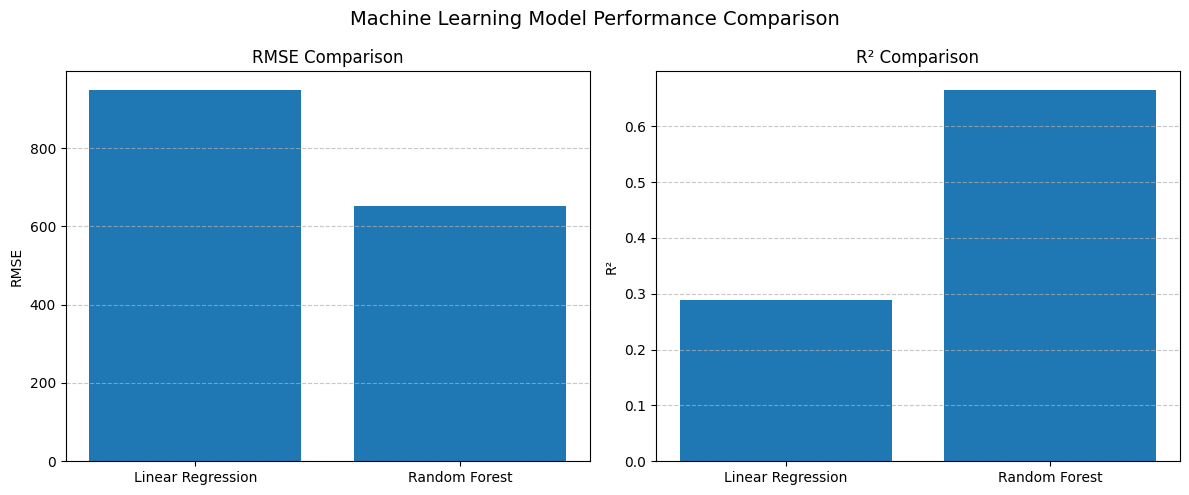

In [0]:
# Model comparison visualisation

import matplotlib.pyplot as plt
import numpy as np

models = ["Linear Regression", "Random Forest"]
rmse_scores = [lr_rmse, rf_rmse]
r2_scores = [lr_r2, rf_r2]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# RMSE chart
axes[0].bar(models, rmse_scores)
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# R2 chart
axes[1].bar(models, r2_scores)
axes[1].set_title("R² Comparison")
axes[1].set_ylabel("R²")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.suptitle("Machine Learning Model Performance Comparison", fontsize=14)

plt.tight_layout()
plt.show()


In [0]:
# Convert time column to timestamp
from pyspark.sql.functions import to_timestamp

df = df.withColumn("timestamp", to_timestamp("time", "dd:MM:yyyy:HH:mm"))

# Create time-based features
from pyspark.sql.functions import hour, month, year, dayofweek

df = df.withColumn("hour", hour("timestamp")) \
       .withColumn("month", month("timestamp")) \
       .withColumn("year", year("timestamp")) \
       .withColumn("day_of_week", dayofweek("timestamp"))

# Split dataset into training and testing sets
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)